# 제주 농산물 가격 예측 최종 고도화 - 일요일 처리 제외 버전 (GeminiCLI8.ipynb)

이 노트북은 GeminiCLI7의 구조를 유지하되, 후처리에서 일요일을 강제로 0으로 바꾸지 않는 버전입니다.
1. **후처리 간소화**: 일요일 명시적 0원 처리를 제거하고 모델의 예측값 유지 (1등 코드 전략)
2. **TG 임계값 적용**: 1등 코드와 동일하게 TG 400원 미만만 0으로 처리
3. **변수 중요도 분석**: VotingRegressor 내 트리 모델들의 평균 기여도 시각화
4. **Clean EMA & 명절 거리**: 고도화된 피처 엔지니어링 전략 유지
5. **5-Fold 교차 검증**: 로컬 MAE/RMSE 확인
6. **최종 결과물**: submission37.csv

## 1. 라이브러리 및 폰트 설정

In [1]:
import os
import pandas as pd
import numpy as np
import datetime
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings("ignore")

try:
    from korean_font import set_korean_font
    set_korean_font()
    print("한글 폰트 설정 완료")
except:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)
한글 폰트 설정 완료


## 2. 데이터 전처리 (이상치 처리)

In [2]:
DATA_PATH = './data/'
train_raw = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
test_raw = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))

outlier_thresholds = {'TG': 20000, 'RD': 5000, 'BC': 8000, 'CB': 2300}
for item, thr in outlier_thresholds.items():
    mask = (train_raw['item'] == item) & (train_raw['price(원/kg)'] > thr)
    if mask.any():
        mean_val = train_raw[(train_raw['item'] == item) & (train_raw['price(원/kg)'] > 0)]['price(원/kg)'].mean()
        train_raw.loc[mask, 'price(원/kg)'] = mean_val

print("이상치 처리 완료")

이상치 처리 완료


## 3. 특성 엔지니어링 (명절 거리 + Clean EMA)

In [3]:
SEOLLAL_DATES = [pd.Timestamp(d) for d in ['2019-02-05', '2020-01-25', '2021-02-12', '2022-02-01', '2023-01-22']]
CHUSEOK_DATES = [pd.Timestamp(d) for d in ['2019-09-13', '2020-10-01', '2021-09-21', '2022-09-10', '2023-09-29']]

def add_features(df):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['year'] = df['timestamp'].dt.year
    df['month'] = df['timestamp'].dt.month
    df['day'] = df['timestamp'].dt.day
    df['dow'] = df['timestamp'].dt.dayofweek
    df['week_num'] = (df['timestamp'] - pd.to_datetime('2019-01-01')).dt.days // 7
    
    df['dist_seollal'] = df['timestamp'].map(lambda d: min(min(abs((d - h).days) for h in SEOLLAL_DATES), 30))
    df['dist_chuseok'] = df['timestamp'].map(lambda d: min(min(abs((d - h).days) for h in CHUSEOK_DATES), 30))
    
    kr_holidays = holidays.KR()
    df['holiday'] = df['timestamp'].apply(lambda x: 1 if x in kr_holidays else 0)
    return df

train = add_features(train_raw)
test = add_features(test_raw)

# 전체 품목 기준 거래 발생 공휴일 보정
no_holi_dates = train[(train['holiday'] == 1) & (train['price(원/kg)'] > 0)]['timestamp'].unique()
train.loc[train['timestamp'].isin(no_holi_dates), 'holiday'] = 0
test.loc[test['timestamp'].isin(no_holi_dates), 'holiday'] = 0

def calculate_clean_ema(series, window):
    s = series.replace(0, np.nan).ffill().bfill().fillna(0)
    return s.shift(1).ewm(span=window, min_periods=1).mean().fillna(0)

for w in [7, 30]:
    train[f'ema_{w}'] = train.groupby(['item', 'corporation', 'location'])['price(원/kg)'].transform(lambda x: calculate_clean_ema(x, w))

last_ema = train.groupby(['item', 'corporation', 'location'])[[f'ema_{w}' for w in [7, 30]]].last().reset_index()
test = pd.merge(test, last_ema, on=['item', 'corporation', 'location'], how='left').fillna(0)

print("특성 엔지니어링 완료")

특성 엔지니어링 완료


## 4. 모델링 준비 (Indexing 보정)

In [4]:
le_cols = ['item', 'corporation', 'location']
le_dict = {col: LabelEncoder().fit(train[col]) for col in le_cols}
for col in le_cols:
    train[col] = le_dict[col].transform(train[col])
    test[col] = le_dict[col].transform(test[col])

item_codes = {name: le_dict['item'].transform([name])[0] for name in le_dict['item'].classes_}
train['target'] = np.where(train['item'] == item_codes['TG'], np.sqrt(train['price(원/kg)']), train['price(원/kg)'])

features = ['item', 'corporation', 'location', 'year', 'month', 'day', 'dow', 'week_num', 'holiday', 'dist_seollal', 'dist_chuseok', 'ema_7', 'ema_30']

scaler = StandardScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train[features]), columns=features)
test_scaled = pd.DataFrame(scaler.transform(test[features]), columns=features)
print("모델링 준비 완료")

모델링 준비 완료


## 5. 5-Fold 학습 및 변수 중요도 추출

Group 1: TG 학습...
Fold 1 | MAE: 1019.12
Fold 2 | MAE: 945.24
Fold 3 | MAE: 983.03
Fold 4 | MAE: 1033.40
Fold 5 | MAE: 1010.01
==> TG Overall | MAE: 998.16 | RMSE: 1660.29


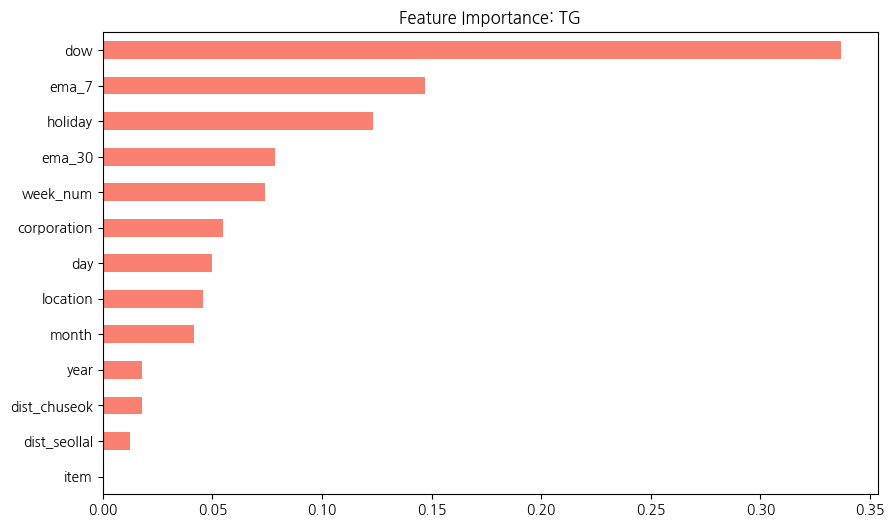

Group 2: RD & CR 학습...
Fold 1 | MAE: 150.00
Fold 2 | MAE: 151.29
Fold 3 | MAE: 147.98
Fold 4 | MAE: 147.96
Fold 5 | MAE: 148.47
==> RD_CR Overall | MAE: 149.14 | RMSE: 266.80


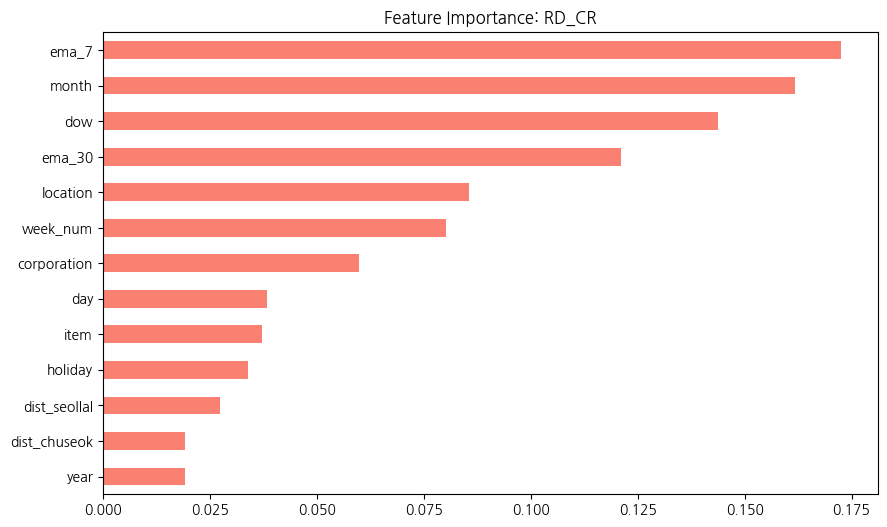

Group 3: BC & CB 학습...
Fold 1 | MAE: 316.07
Fold 2 | MAE: 319.65
Fold 3 | MAE: 319.70
Fold 4 | MAE: 312.79
Fold 5 | MAE: 322.58
==> BC_CB Overall | MAE: 318.16 | RMSE: 553.71


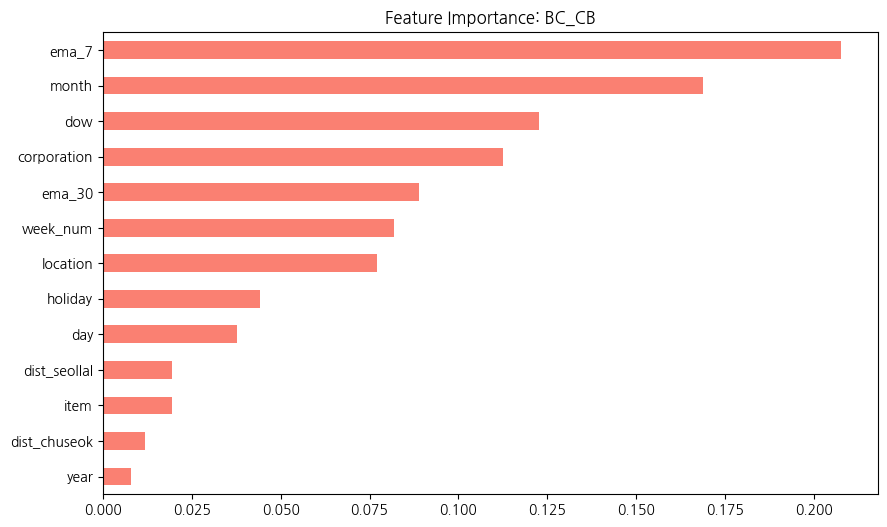

In [5]:
def train_group_with_importance(df, scaled_df, target_col, test_scaled_df, is_tg=False, group_name=""):
    df = df.reset_index(drop=True)
    scaled_df = scaled_df.reset_index(drop=True)
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_preds = []
    oof_preds = np.zeros(len(df))
    importances = pd.DataFrame(index=features)
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
        X_train, y_train = scaled_df.iloc[train_idx], df[target_col].iloc[train_idx]
        X_val, y_val = scaled_df.iloc[val_idx], df[target_col].iloc[val_idx]
        
        ensemble = VotingRegressor([
            ('lgbm', LGBMRegressor(n_estimators=1000, learning_rate=0.01, random_state=42, verbose=-1)),
            ('xgb', XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)),
            ('cat', CatBoostRegressor(iterations=1000, learning_rate=0.01, random_state=42, verbose=0)),
            ('ridge', Ridge(alpha=1.0))
        ])
        
        ensemble.fit(X_train, y_train)
        val_pred = ensemble.predict(X_val)
        oof_preds[val_idx] = val_pred
        
        # 변수 중요도 추출
        lgbm_imp = ensemble.named_estimators_['lgbm'].feature_importances_
        xgb_imp = ensemble.named_estimators_['xgb'].feature_importances_
        cat_imp = ensemble.named_estimators_['cat'].get_feature_importance()
        importances[f'fold_{fold+1}'] = (lgbm_imp/lgbm_imp.sum() + xgb_imp/xgb_imp.sum() + cat_imp/cat_imp.sum()) / 3
        
        # 검증 점수 산출 (일요일 보정 없이 순수 모델 성능 측정)
        y_val_orig = np.power(y_val, 2) if is_tg else y_val
        val_pred_orig = np.power(np.maximum(0, val_pred), 2) if is_tg else np.maximum(0, val_pred)
        
        print(f"Fold {fold+1} | MAE: {mean_absolute_error(y_val_orig, val_pred_orig):.2f}")
        fold_preds.append(ensemble.predict(test_scaled_df))
    
    # 그룹 전체 결과
    oof_orig = np.power(np.maximum(0, oof_preds), 2) if is_tg else np.maximum(0, oof_preds)
    target_orig = np.power(df[target_col], 2) if is_tg else df[target_col]
    
    print(f"==> {group_name} Overall | MAE: {mean_absolute_error(target_orig, oof_orig):.2f} | RMSE: {np.sqrt(mean_squared_error(target_orig, oof_orig)):.2f}")
    
    # 중요도 시각화
    plt.figure(figsize=(10, 6))
    importances.mean(axis=1).sort_values().plot(kind='barh', color='salmon', title=f'Feature Importance: {group_name}')
    plt.show()
    
    return np.mean(fold_preds, axis=0)

print("Group 1: TG 학습...")
tg_mask = train['item'] == item_codes['TG']
pred_tg = train_group_with_importance(train[tg_mask], train_scaled[tg_mask], 'target', test_scaled[test['item']==item_codes['TG']], True, "TG")

print("Group 2: RD & CR 학습...")
rd_cr_mask = train['item'].isin([item_codes['RD'], item_codes['CR']])
pred_rd_cr = train_group_with_importance(train[rd_cr_mask], train_scaled[rd_cr_mask], 'target', test_scaled[test['item'].isin([item_codes['RD'], item_codes['CR']])], False, "RD_CR")

print("Group 3: BC & CB 학습...")
bc_cb_mask = train['item'].isin([item_codes['BC'], item_codes['CB']])
pred_bc_cb = train_group_with_importance(train[bc_cb_mask], train_scaled[bc_cb_mask], 'target', test_scaled[test['item'].isin([item_codes['BC'], item_codes['CB']])], False, "BC_CB")

## 6. 후처리 및 결과 결합 (No Sunday Fix)

In [6]:
test_tg = test[test['item'] == item_codes['TG']].copy()
test_rd_cr = test[test['item'].isin([item_codes['RD'], item_codes['CR']])].copy()
test_bc_cb = test[test['item'].isin([item_codes['BC'], item_codes['CB']])].copy()

test_tg['answer'] = np.power(np.maximum(0, pred_tg), 2)
test_rd_cr['answer'] = np.maximum(0, pred_rd_cr)
test_bc_cb['answer'] = np.maximum(0, pred_bc_cb)

# 최종 후처리: 일요일 처리는 생략하고 1등 임계값만 적용
test_tg.loc[test_tg['answer'] < 400, 'answer'] = 0

total_results = pd.concat([test_tg, test_rd_cr, test_bc_cb])
print("예측 결과 결합 완료 (일요일 처리 미적용)")

예측 결과 결합 완료 (일요일 처리 미적용)


## 7. 시각화 (최종 예측 추세)

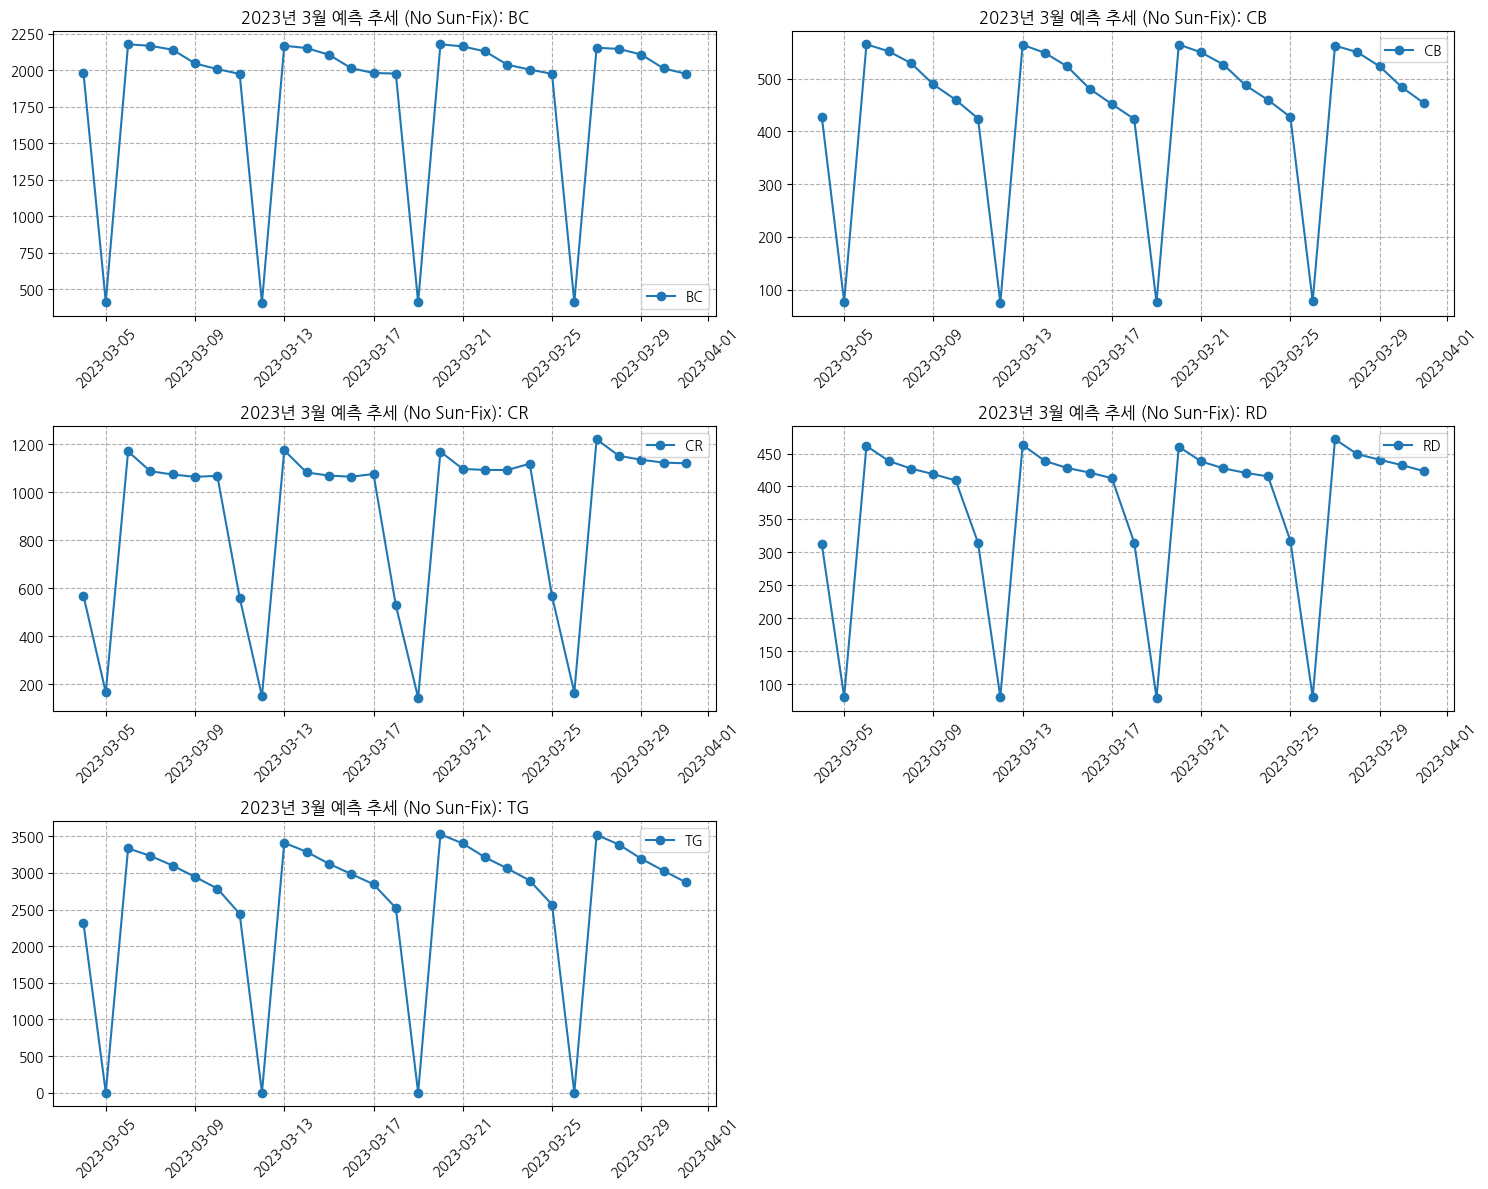

In [7]:
plt.figure(figsize=(15, 12))
items = le_dict['item'].classes_
for i, item_name in enumerate(items):
    plt.subplot(3, 2, i+1)
    item_code = le_dict['item'].transform([item_name])[0]
    data = total_results[total_results['item'] == item_code]
    daily = data.groupby('timestamp')['answer'].mean()
    plt.plot(daily.index, daily.values, marker='o', label=item_name)
    plt.title(f'2023년 3월 예측 추세 (No Sun-Fix): {item_name}')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--')
    plt.legend()
plt.tight_layout()
plt.show()

## 8. 결과 저장

In [8]:
sample_sub = pd.read_csv(os.path.join(DATA_PATH, 'sample_submission.csv'))
submission = pd.merge(sample_sub[['ID']], total_results[['ID', 'answer']], on='ID', how='left')
submission.to_csv('submission37.csv', index=False)
print("submission37.csv 저장 완료")

submission37.csv 저장 완료
